#  CarbonWise — Carbon Emission Prediction

---

## Project Objectives

| # | Objective | Method |
|---|-----------|--------|
| **O1** | Identify the most influential features | Correlation heatmap + coefficient ranking |
| **O2** | Test whether frequent air travel significantly increases carbon footprint | t-test: low vs high flight frequency groups |
| **O3** | Reduce redundancy by removing less significant features | Drop low-correlation + high-collinearity features |
| **O4** | Build a Simple Linear Regression model using selected features | `sklearn` Simple Linear Regression (single predictor) |
| **O5** | Validate the model — test that features actually influence emissions | OLS F-test (global model significance) |

---

## 1. Setup & Data Loading

In [1]:
!git clone https://github.com/Dakshgupta25/CarbonWise.git
%cd CarbonWise

d:\Desktop\D.S\0_Projects\CarbonWise\notebooks\CarbonWise


Cloning into 'CarbonWise'...


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Set consistent plot style throughout the notebook
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

# Load the dataset
df = pd.read_excel("data/Carbon Emission.xlsx")

# Preview the first few rows to understand structure
df.head()

,Body Type,Sex,Diet,How Often Shower,Heating Energy Source,Transport,Vehicle Type,Social Activity,Monthly Grocery Bill,Frequency of Traveling by Air,Vehicle Monthly Distance Km,Waste Bag Size,Waste Bag Weekly Count,How Long TV PC Daily Hour,How Many New Clothes Monthly,How Long Internet Daily Hour,Energy efficiency,Recycling,Cooking_With,CarbonEmission
0,overweight,female,pescatarian,daily,coal,public,NaN,often,230,frequently,210,large,4,7,26,1,No,['Metal'],"['Stove', 'Oven']",2238
1,obese,female,vegetarian,less frequently,natural gas,walk/bicycle,NaN,often,114,rarely,9,extra large,3,9,38,5,No,['Metal'],"['Stove', 'Microwave']",1892
2,overweight,male,omnivore,more frequently,wood,private,petrol,never,138,never,2472,small,1,14,47,6,Sometimes,['Metal'],"['Oven', 'Microwave']",2595
3,overweight,male,omnivore,twice a day,wood,walk/bicycle,NaN,sometimes,157,rarely,74,medium,3,20,5,7,Sometimes,"['Paper', 'Plastic', 'Glass', 'Metal']","['Microwave', 'Grill', 'Airfryer']",1074
4,obese,female,vegetarian,daily,coal,private,diesel,often,266,very frequently,8457,large,1,3,5,6,Yes,['Paper'],['Oven'],4743


**Understanding:** We import all required libraries upfront and load the raw dataset. Setting a consistent plot theme ensures all visualizations look uniform throughout the notebook.

---
## 2. Data Cleaning

In [3]:
# Basic shape and type overview
print(f"Shape: {df.shape}")
print(f"\nDuplicated rows: {df.duplicated().sum()}")
print("\nData Types:")
print(df.dtypes)

Shape: (10000, 20)

Duplicated rows: 0

Data Types:
Body Type                        object
Sex                              object
Diet                             object
How Often Shower                 object
Heating Energy Source            object
Transport                        object
Vehicle Type                     object
Social Activity                  object
Monthly Grocery Bill              int64
Frequency of Traveling by Air    object
Vehicle Monthly Distance Km       int64
Waste Bag Size                   object
Waste Bag Weekly Count            int64
How Long TV PC Daily Hour         int64
How Many New Clothes Monthly      int64
How Long Internet Daily Hour      int64
Energy efficiency                object
Recycling                        object
Cooking_With                     object
CarbonEmission                    int64
dtype: object


**Understanding:** We check the dataset dimensions, look for duplicate rows, and review each column's data type to know which columns are categorical vs numerical before any further processing.

In [4]:
# Standardise column names: replace spaces with underscores
df.columns = df.columns.str.replace(' ', '_')

# Separate categorical and numerical columns for targeted treatment
cat_col = df.columns[df.dtypes == object]
num_col = df.columns[df.dtypes != object]

print("Categorical columns:", list(cat_col))
print("Numerical columns :", list(num_col))

Categorical columns: ['Body_Type', 'Sex', 'Diet', 'How_Often_Shower', 'Heating_Energy_Source', 'Transport', 'Vehicle_Type', 'Social_Activity', 'Frequency_of_Traveling_by_Air', 'Waste_Bag_Size', 'Energy_efficiency', 'Recycling', 'Cooking_With']
Numerical columns : ['Monthly_Grocery_Bill', 'Vehicle_Monthly_Distance_Km', 'Waste_Bag_Weekly_Count', 'How_Long_TV_PC_Daily_Hour', 'How_Many_New_Clothes_Monthly', 'How_Long_Internet_Daily_Hour', 'CarbonEmission']


**Understanding:** Column names are cleaned to remove spaces (makes them easier to reference in code). Columns are then split into categorical and numerical groups so we can apply appropriate cleaning steps to each group separately.

In [5]:
# Check missing values in both column groups
print("Missing values — Numerical:")
print(df[num_col].isnull().sum())

print("\nMissing values — Categorical:")
print(df[cat_col].isnull().sum())

Missing values — Numerical:
Monthly_Grocery_Bill            0
Vehicle_Monthly_Distance_Km     0
Waste_Bag_Weekly_Count          0
How_Long_TV_PC_Daily_Hour       0
How_Many_New_Clothes_Monthly    0
How_Long_Internet_Daily_Hour    0
CarbonEmission                  0
dtype: int64

Missing values — Categorical:
Body_Type                           0
Sex                                 0
Diet                                0
How_Often_Shower                    0
Heating_Energy_Source               0
Transport                           0
Vehicle_Type                     6721
Social_Activity                     0
Frequency_of_Traveling_by_Air       0
Waste_Bag_Size                      0
Energy_efficiency                   0
Recycling                           0
Cooking_With                        0
dtype: int64


**Understanding:** We identify where null values exist. This guides our imputation strategy — different column types need different handling (e.g., logical fill based on related columns for categorical, vs statistical fill for numerical).

In [6]:
# For rows where transport mode is public or walk/bicycle,
df['Vehicle_Type'] = df.apply(
    lambda row: 'No Vehicle'
    if pd.isnull(row['Vehicle_Type']) and row['Transport'] in ['public', 'walk/bicycle']
    else row['Vehicle_Type'],
    axis=1
)

print("Remaining nulls in categorical columns:")
print(df[cat_col].isnull().sum())

Remaining nulls in categorical columns:
Body_Type                        0
Sex                              0
Diet                             0
How_Often_Shower                 0
Heating_Energy_Source            0
Transport                        0
Vehicle_Type                     0
Social_Activity                  0
Frequency_of_Traveling_by_Air    0
Waste_Bag_Size                   0
Energy_efficiency                0
Recycling                        0
Cooking_With                     0
dtype: int64


**Understanding:** Instead of blindly dropping or guessing, we use domain logic — if someone uses public transport or walks, they have no personal vehicle. This is a context-aware imputation that preserves data integrity.

---
## 3. Exploratory Data Analysis (EDA)

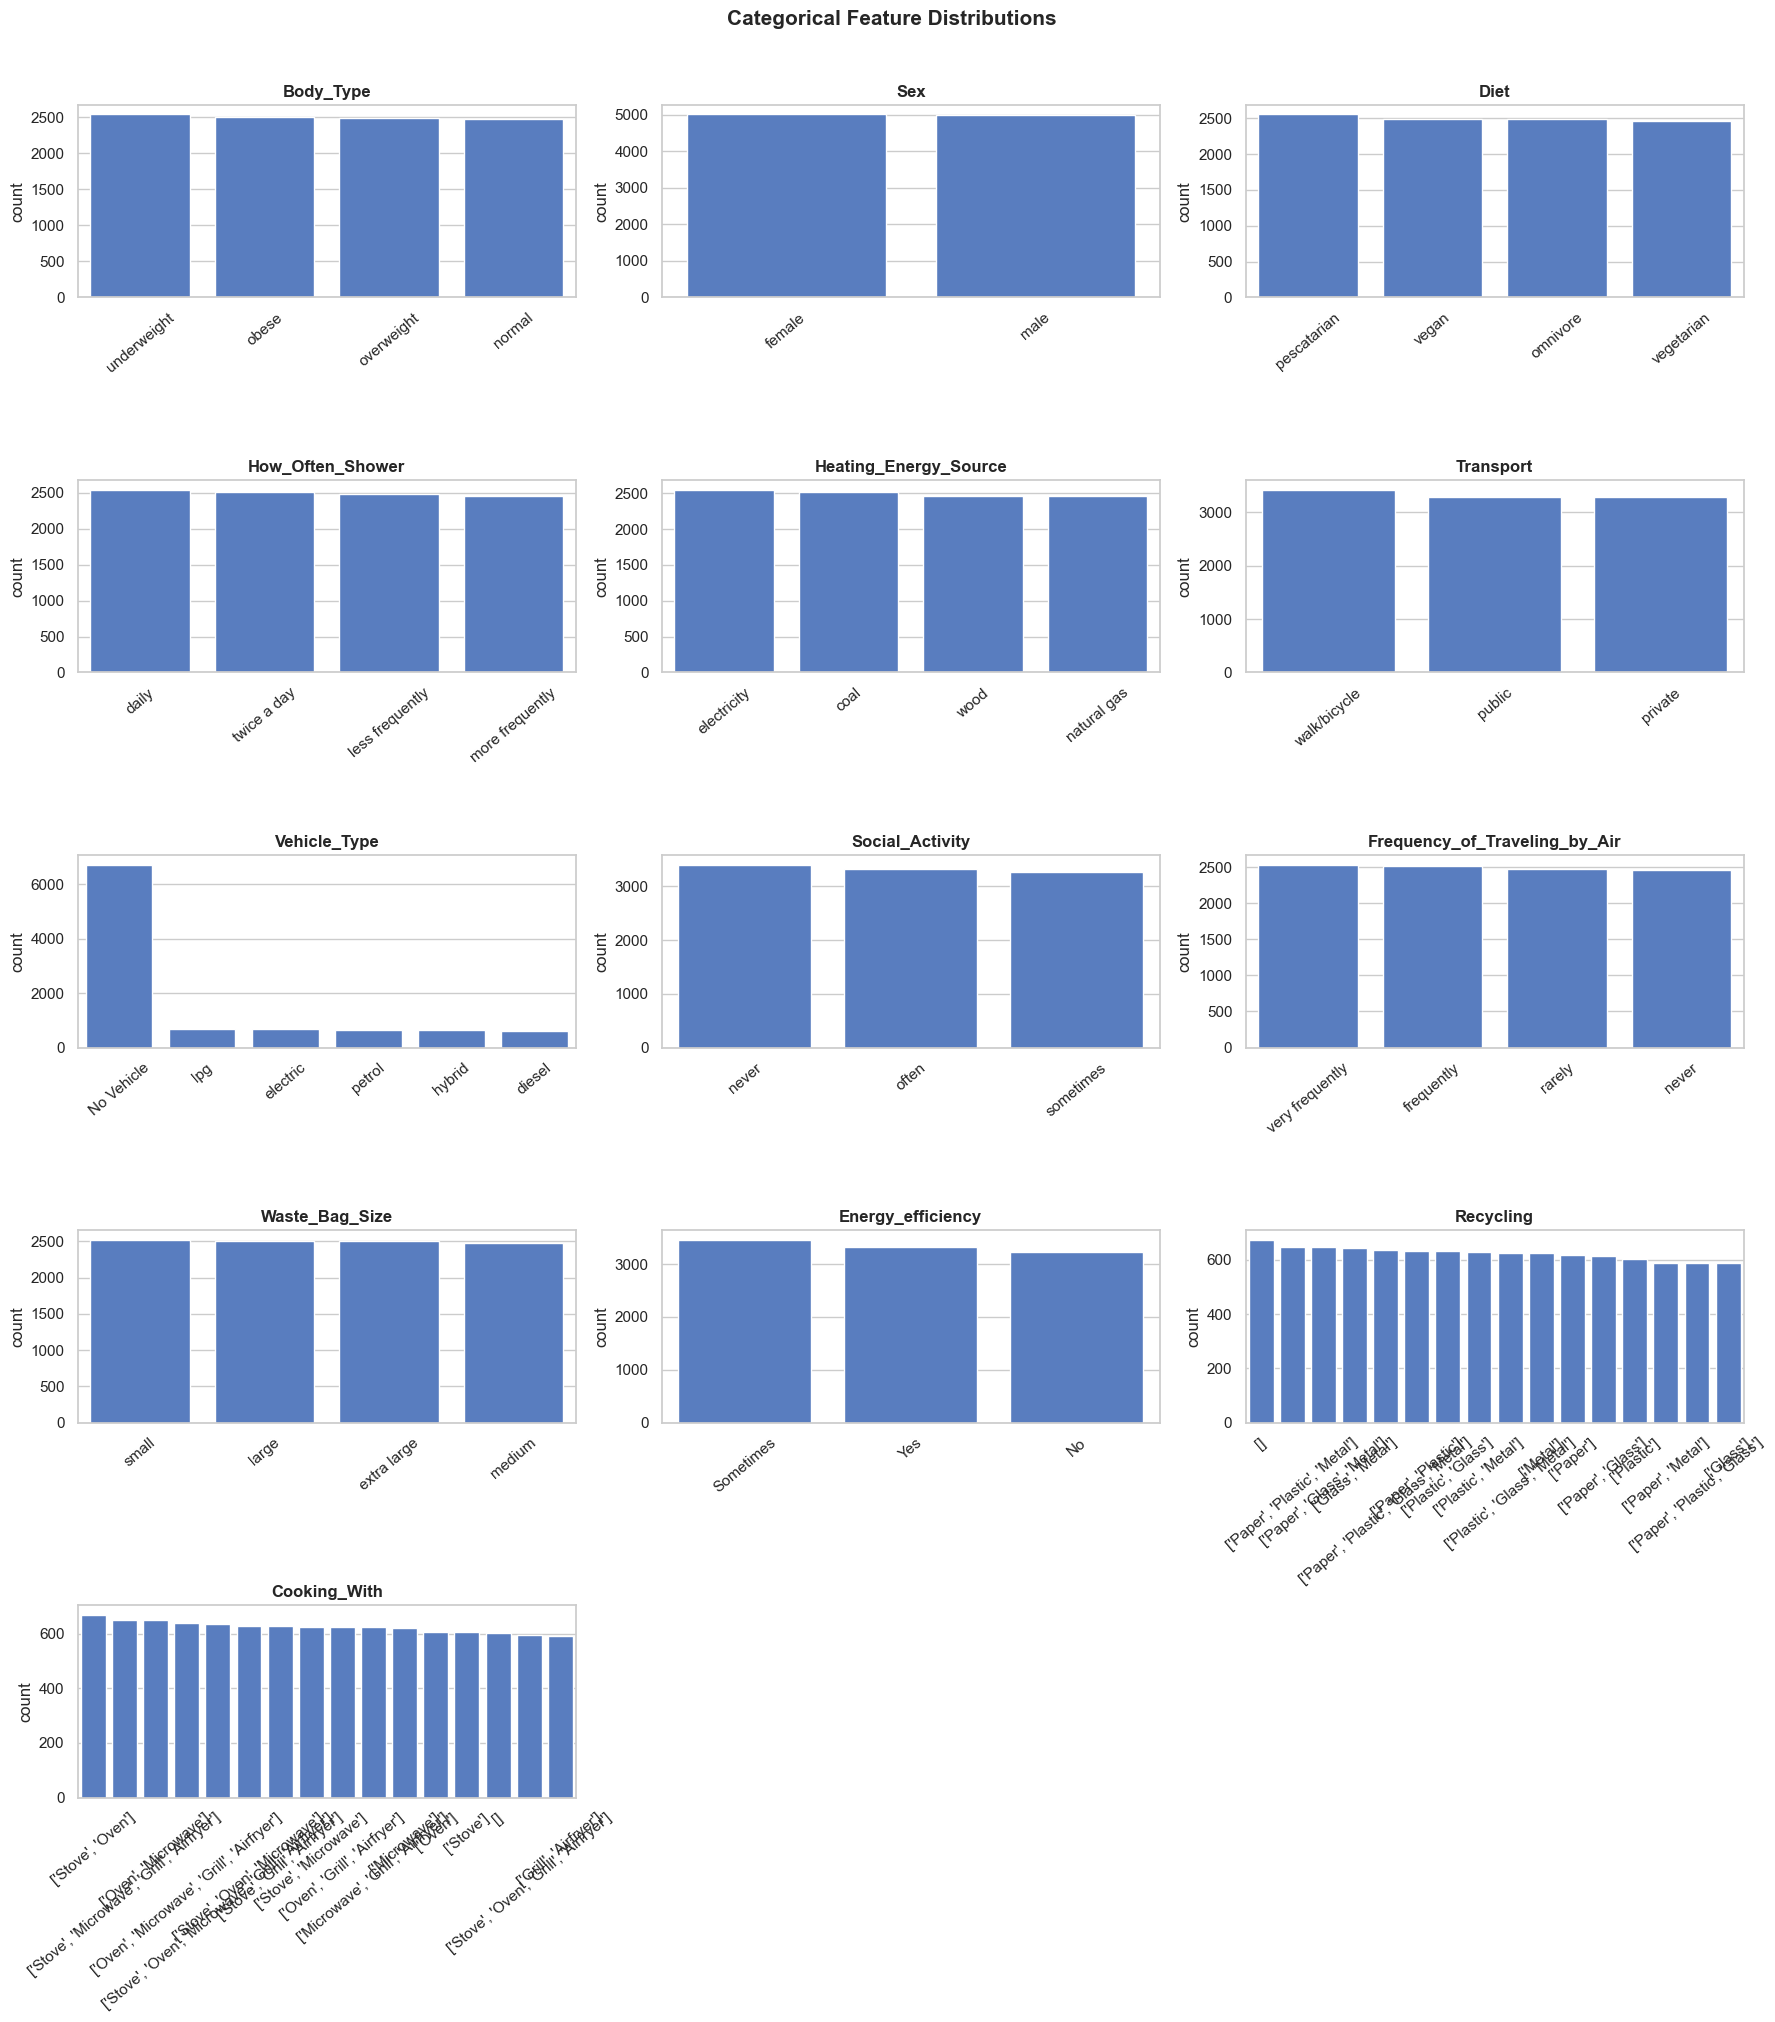

In [7]:
# Distribution of all categorical features using count plots
cols = 3
rows = (len(cat_col) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(cat_col):
    sns.countplot(x=df[col], ax=axes[i], order=df[col].value_counts().index)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=40)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Categorical Feature Distributions", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Understanding:** Count plots show how many records fall into each category. This reveals class imbalances (e.g., one vehicle type dominating) and gives us a feel for the data composition before modelling.

In [8]:
# Identify numerical feature columns (excluding target)
target = 'CarbonEmission'
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols.remove(target)

# Summary statistics for numerical features
stats_df = pd.DataFrame({
    'Mean'    : df[num_cols].mean().round(2),
    'Median'  : df[num_cols].median().round(2),
    'Std Dev' : df[num_cols].std().round(2),
    'Skewness': df[num_cols].skew().round(2),
    'Min'     : df[num_cols].min(),
    'Max'     : df[num_cols].max()
})

print("Numerical Feature Statistics:")
stats_df

Numerical Feature Statistics:


,Mean,Median,Std Dev,Skewness,Min,Max
Monthly_Grocery_Bill,173.88,173.0,72.23,0.00,50,299
Vehicle_Monthly_Distance_Km,2031.49,823.0,2769.72,1.48,0,9999
Waste_Bag_Weekly_Count,4.02,4.0,1.99,-0.01,1,7
How_Long_TV_PC_Daily_Hour,12.14,12.0,7.11,-0.03,0,24
How_Many_New_Clothes_Monthly,25.11,25.0,14.70,-0.01,0,50
How_Long_Internet_Daily_Hour,11.89,12.0,7.28,0.02,0,24


**Understanding:** Descriptive statistics summarise the spread and shape of each numerical feature. High skewness values (>1 or <-1) indicate a non-normal distribution that may need transformation. Mean vs median differences also signal skew and outliers.

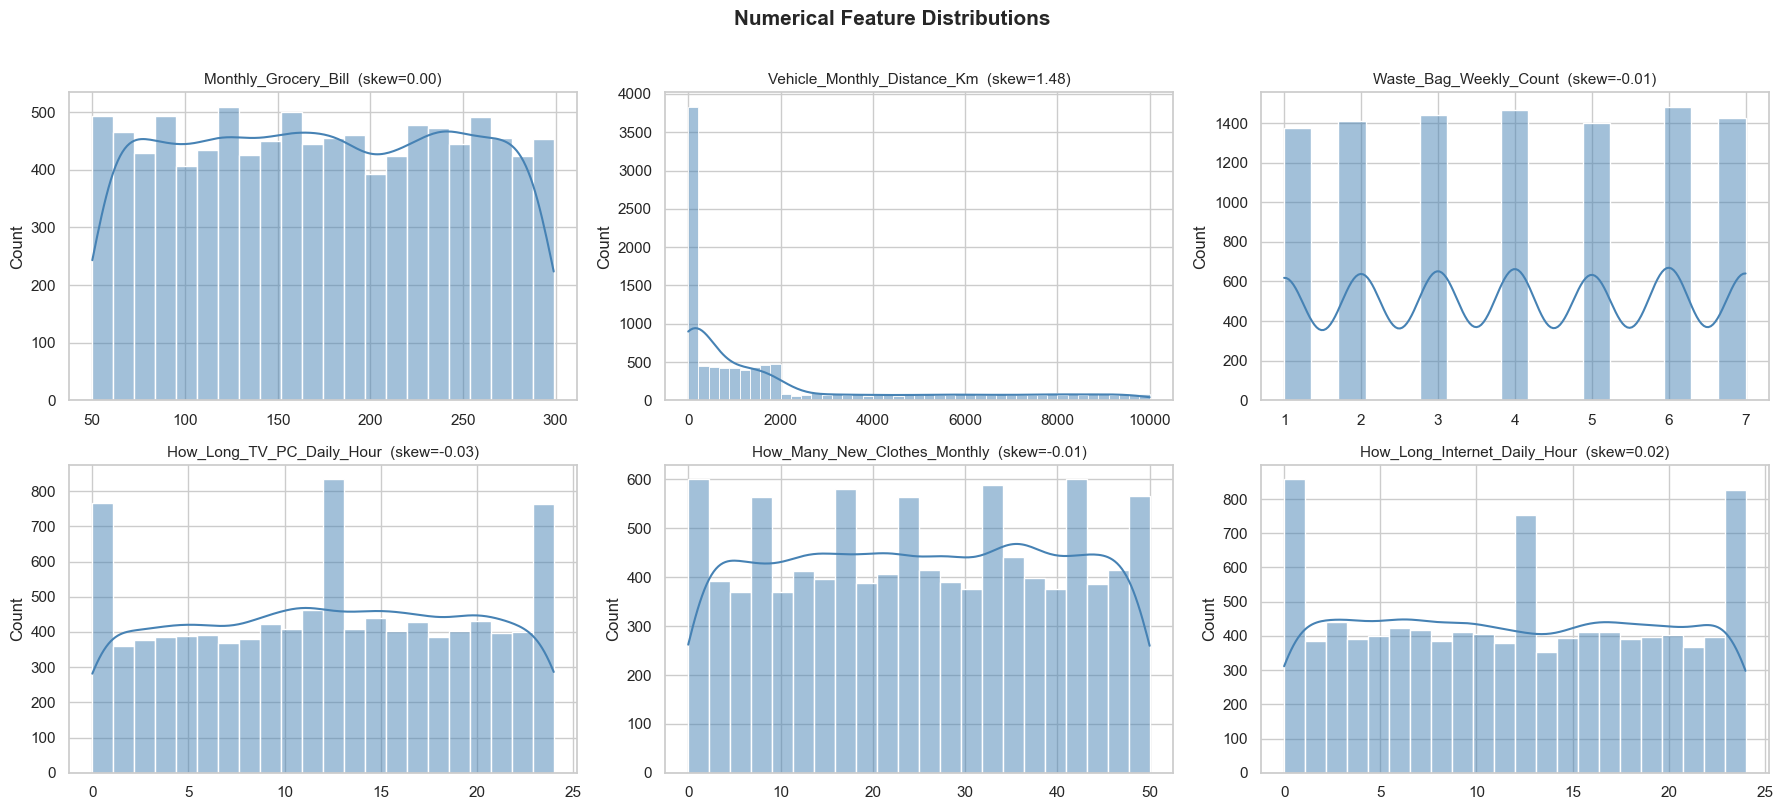

In [9]:
# Distribution plots (histograms + KDE) for numerical features
cols = 3
rows = (len(num_cols) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f"{col}  (skew={df[col].skew():.2f})", fontsize=11)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Numerical Feature Distributions", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Understanding:** Histograms with KDE (Kernel Density Estimate) overlay show the actual shape of each distribution. The skewness value in the title confirms visually what the statistics showed — helping us decide which features need log transformation.

---
## 6. Objective O1 — Most Influential Features


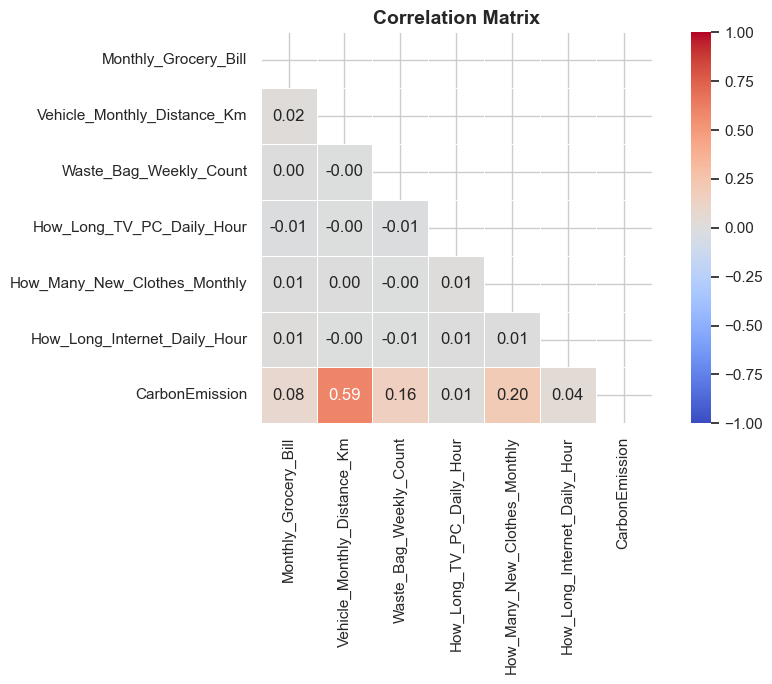

In [10]:
# Correlation heatmap — shows linear relationships between numerical features and target
plt.figure(figsize=(10, 7))
corr_cols = num_cols + [target]
corr = df[corr_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))  # only lower triangle
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap='coolwarm', vmin=-1, vmax=1,
    square=True, linewidths=0.5
)
plt.title("Correlation Matrix", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Understanding:** The heatmap shows pairwise linear correlation coefficients. Values close to +1 or -1 mean strong linear relationships. We focus on the last row/column (CarbonEmission) to see which features are most predictive for our target variable.The most corelated feature is Vehicle_Monthly_Distance_Km

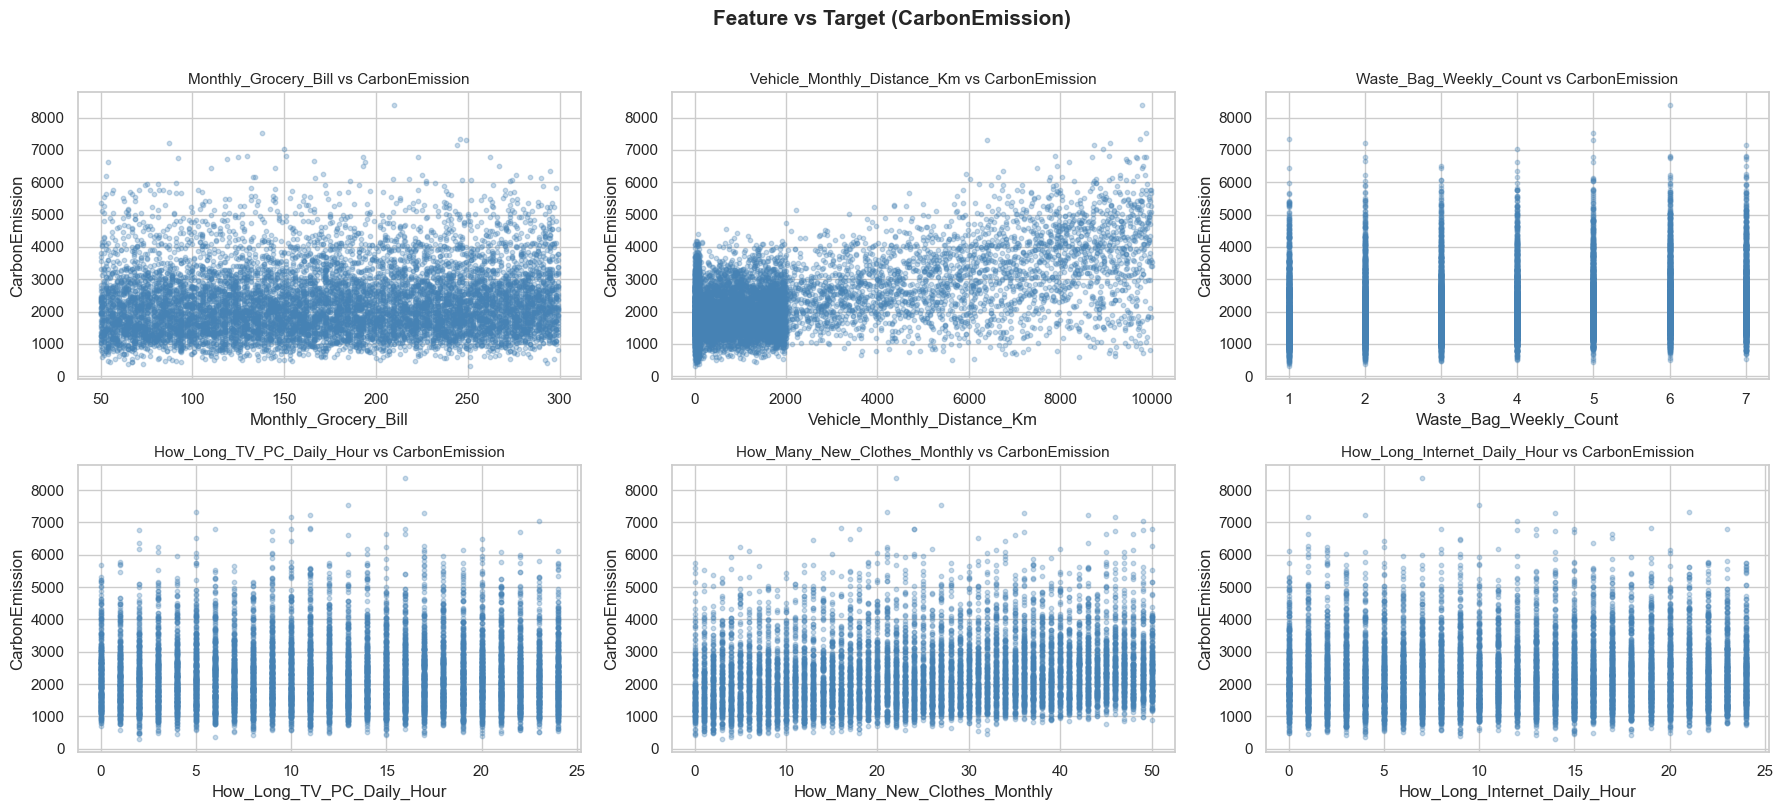

In [11]:
# Scatter plots: each numerical feature vs the target (CarbonEmission)
cols = 3
rows = (len(num_cols) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].scatter(df[col], df[target], alpha=0.3, s=10, color='steelblue')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('CarbonEmission')
    axes[i].set_title(f"{col} vs CarbonEmission", fontsize=11)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Feature vs Target (CarbonEmission)", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Understanding:** Scatter plots reveal the nature of the relationship between each predictor and the target. A clear upward/downward trend suggests a useful linear predictor. Scattered clouds suggest weak or non-linear relationships.

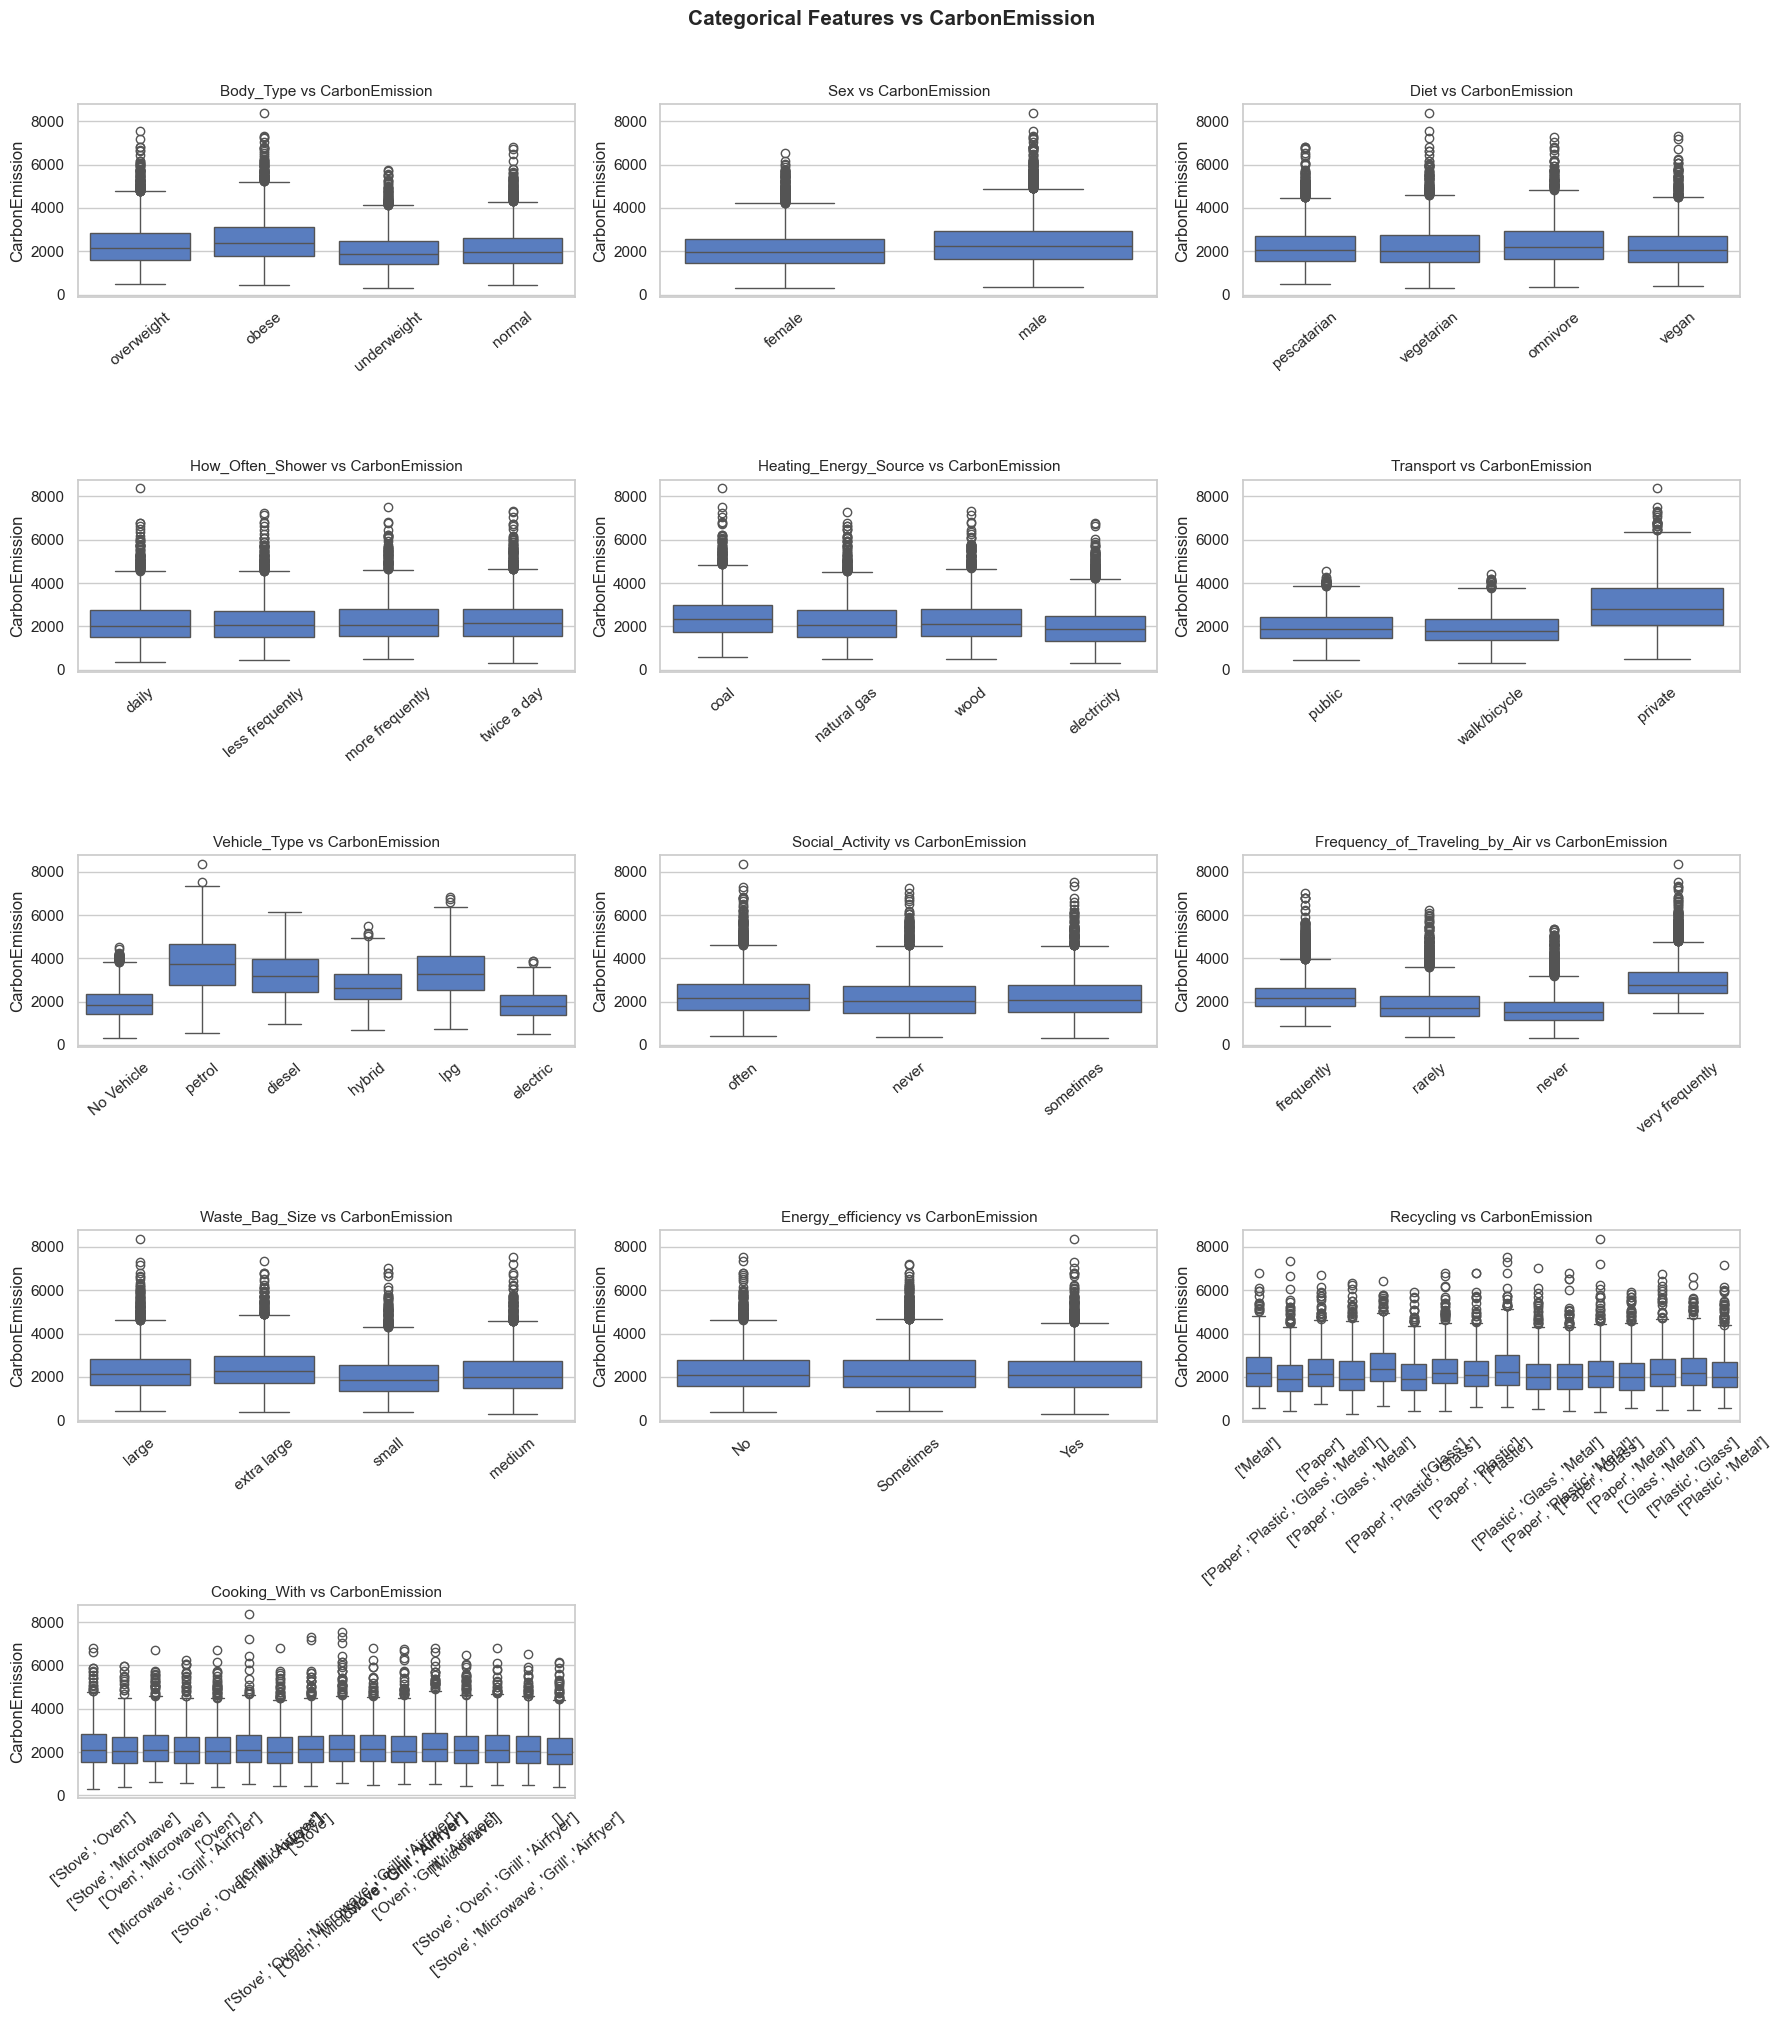

In [12]:
# Box plots: how CarbonEmission varies across categories
cat_cols = df.select_dtypes(include=['object']).columns
cols = 3
rows = (len(cat_cols) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.boxplot(x=col, y=target, data=df, ax=axes[i])
    axes[i].set_title(f"{col} vs CarbonEmission", fontsize=11)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=40)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Categorical Features vs CarbonEmission", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Understanding:** Box plots compare the distribution of CarbonEmission across each category. Large differences in median values between categories indicate that feature is a meaningful predictor. Overlapping boxes suggest less discriminative power.

---
## 4. Outlier Treatment & Feature Transformation

In [13]:
# Detect outliers using IQR method before treatment
outlier_info = []
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    count = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    outlier_info.append([col, count, round((count / len(df)) * 100, 2)])

outlier_df = pd.DataFrame(outlier_info, columns=['Column', 'Outliers', 'Percent (%)'])
print(outlier_df)

                         Column  Outliers  Percent (%)
0          Monthly_Grocery_Bill         0         0.00
1   Vehicle_Monthly_Distance_Km      1294        12.94
2        Waste_Bag_Weekly_Count         0         0.00
3     How_Long_TV_PC_Daily_Hour         0         0.00
4  How_Many_New_Clothes_Monthly         0         0.00
5  How_Long_Internet_Daily_Hour         0         0.00


**Understanding:** The IQR (Interquartile Range) method flags values that fall more than 1.5×IQR below Q1 or above Q3 as outliers. Knowing how many outliers exist per column helps us decide the right treatment strategy.

In [14]:
# Apply log transformation for heavily skewed columns,
df_clean = df.copy()
skewed_cols = df[num_cols].skew().abs()

for col in num_cols:
    # Log-transform features with high skew (abs skew > 1)
    if skewed_cols[col] > 1:
        df_clean[col] = np.log1p(df_clean[col])

    # Cap extreme values using IQR bounds
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    df_clean[col] = np.clip(df_clean[col], Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

# Confirm outliers have been eliminated
print("Remaining outliers after treatment:")
for col in num_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    count = ((df_clean[col] < Q1 - 1.5 * IQR) | (df_clean[col] > Q3 + 1.5 * IQR)).sum()
    print(f"  {col}: {count}")

Remaining outliers after treatment:
  Monthly_Grocery_Bill: 0
  Vehicle_Monthly_Distance_Km: 0
  Waste_Bag_Weekly_Count: 0
  How_Long_TV_PC_Daily_Hour: 0
  How_Many_New_Clothes_Monthly: 0
  How_Long_Internet_Daily_Hour: 0


**Understanding:** Two-step treatment — (1) log1p transformation compresses heavily skewed distributions towards normality, which is important for linear regression assumptions; (2) IQR capping clips any remaining extremes without losing rows. After treatment, all counts should be 0.

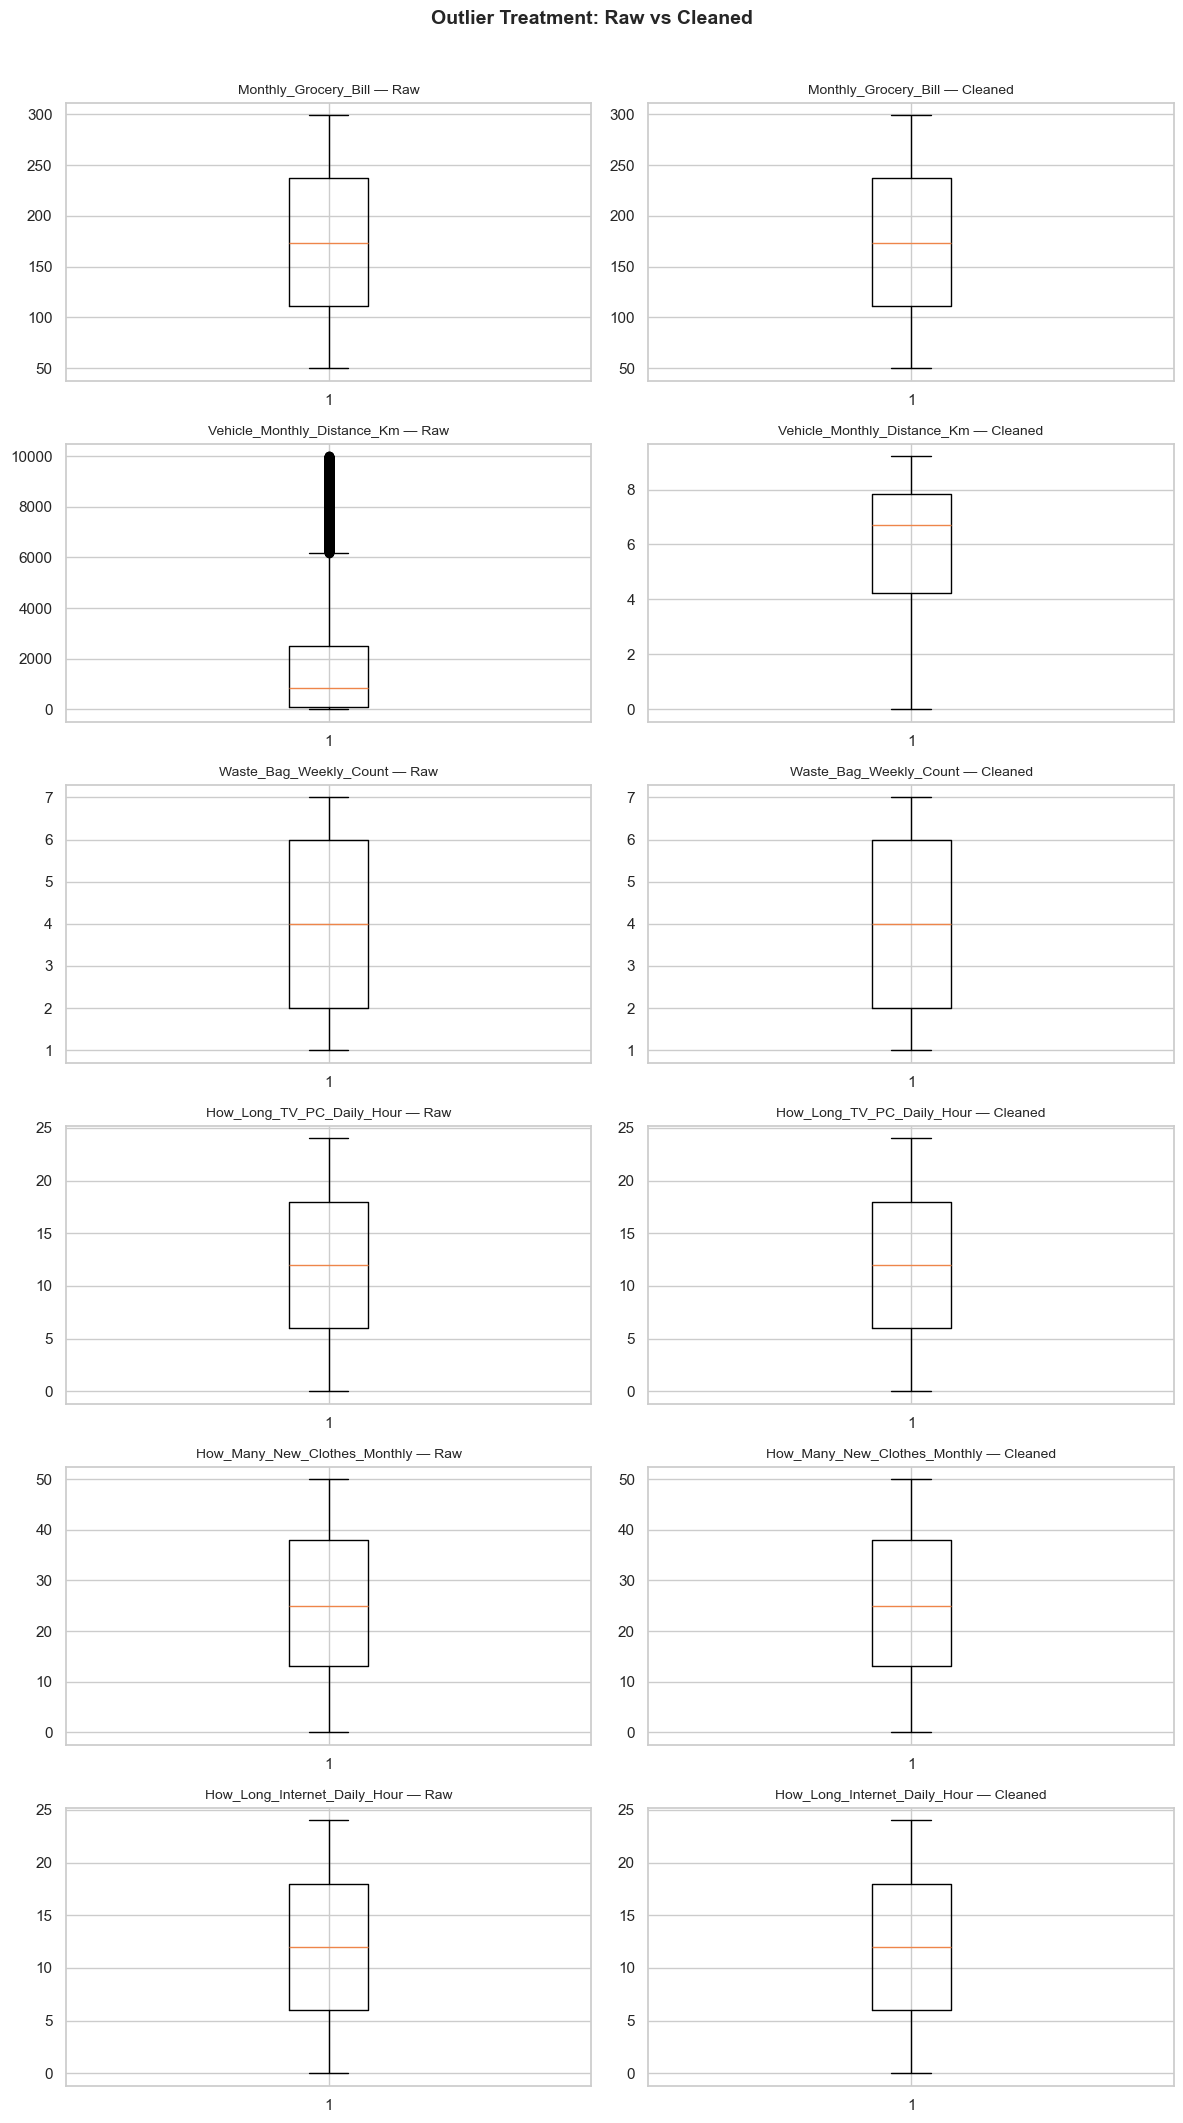

In [15]:
# Side-by-side boxplots: Raw vs Cleaned for each numerical feature
fig, axes = plt.subplots(len(num_cols), 2, figsize=(12, 3.5 * len(num_cols)))

for i, col in enumerate(num_cols):
    axes[i, 0].boxplot(df[col].dropna())
    axes[i, 0].set_title(f"{col} — Raw", fontsize=10)

    axes[i, 1].boxplot(df_clean[col].dropna())
    axes[i, 1].set_title(f"{col} — Cleaned", fontsize=10)

plt.suptitle("Outlier Treatment: Raw vs Cleaned", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Understanding:** Visual confirmation that outlier treatment worked. Comparing raw vs cleaned boxplots shows the reduction in extreme whiskers and outlier points — validating that our log + IQR capping approach effectively cleaned the data.

---
## 5. Feature Engineering & Preprocessing

---
##  Objective O3 — Redundancy Reduction 

> Features with low predictive value (`Diet`, `Social_Activity`, `Monthly_Grocery_Bill`, `How_Often_Shower`) will  dropped . Highly correlated feature pairs (r > 0.9) were also removed automatically. This leaves a lean, non-redundant feature set for the model.


In [16]:
# Drop features with low predictive value based on EDA insights
drop_cols = ['Diet', 'Social_Activity', 'Monthly_Grocery_Bill', 'How_Often_Shower']
df_model = df_clean.drop(columns=drop_cols)

# Consolidate rare categories in Cooking_With to avoid excessive dummy columns
top_categories = df_model['Cooking_With'].value_counts().nlargest(5).index
df_model['Cooking_With'] = df_model['Cooking_With'].apply(
    lambda x: x if x in top_categories else 'Other'
)

print("Remaining columns:", df_model.shape[1])
print("Cooking_With categories:", df_model['Cooking_With'].unique())

Remaining columns: 16
Cooking_With categories: ["['Stove', 'Oven']" 'Other' "['Oven', 'Microwave']"
 "['Stove', 'Oven', 'Microwave', 'Grill', 'Airfryer']"
 "['Oven', 'Microwave', 'Grill', 'Airfryer']"
 "['Stove', 'Microwave', 'Grill', 'Airfryer']"]


**Understanding:** We remove features that showed weak or no relationship with CarbonEmission during EDA (low correlation, similar box plot distributions). Rare categories in Cooking_With are grouped as 'Other' to prevent the model from learning noise from tiny categories.

In [17]:
# Separate features (X) and target (y)
X = df_model.drop(target, axis=1)
y = df_model[target]

# 80-20 train-test split with fixed random seed for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set : {X_train.shape}")
print(f"Test set     : {X_test.shape}")

Training set : (8000, 15)
Test set     : (2000, 15)


**Understanding:** We split the data before any encoding or scaling to prevent data leakage — the test set must simulate completely unseen data. 80% for training gives the model enough data to learn, while 20% for testing gives a reliable performance estimate.

In [18]:
# One-hot encode categorical columns (drop_first avoids dummy variable trap)
X_train = pd.get_dummies(X_train, drop_first=True)
X_test  = pd.get_dummies(X_test,  drop_first=True)

# Align test set columns to training set (fill any missing with 0)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# Remove highly correlated features (r > 0.9) to reduce multicollinearity
corr_matrix = X_train.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]
X_train = X_train.drop(columns=to_drop)
X_test  = X_test.drop(columns=to_drop)

# Scale features — Linear Regression is sensitive to feature magnitudes
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only
X_test_scaled  = scaler.transform(X_test)         # transform test using train stats

print(f"Final feature count: {X_train.shape[1]}")
print(f"Dropped for high correlation: {to_drop}")

Final feature count: 47
Dropped for high correlation: []


**Understanding:** Three important steps here — (1) One-hot encoding converts categorical text into numeric dummy variables that linear regression can process; (2) Dropping highly correlated features (>0.9) removes multicollinearity which inflates coefficient errors in linear regression; (3) StandardScaler normalises all features to zero mean and unit variance so no single feature dominates due to its scale.

---
## 8. Objective O4 — Simple Linear Regression Model

> **SLR equation:** `CarbonEmission = β₀ + β₁ × Vehicle_Monthly_Distance_Km`

We use a **single predictor** — the feature most correlated with CarbonEmission — keeping the model simple and interpretable.


In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Single predictor — this is what makes it SIMPLE Linear Regression
X_slr = df_clean[['Vehicle_Monthly_Distance_Km']]
y_slr = df_clean['CarbonEmission']

X_train_slr, X_test_slr, y_train_slr, y_test_slr = train_test_split(
    X_slr, y_slr, test_size=0.2, random_state=42
)

slr = LinearRegression()
slr.fit(X_train_slr, y_train_slr)
y_pred_slr = slr.predict(X_test_slr)

b0 = slr.intercept_
b1 = slr.coef_[0]

print('=' * 55)
print('  SIMPLE LINEAR REGRESSION — CarbonWise')
print('=' * 55)
print(f'  Equation : CO2 = {b0:.2f} + {b1:.4f} x Vehicle_km')
print(f'  β₀ (intercept)  : {b0:.4f} kg')
print(f'  β₁ (slope)      : {b1:.4f} kg per km')
print(f'  Interpretation  : Each additional km/month adds ~{b1:.2f} kg CO2/year')
print('=' * 55)


  SIMPLE LINEAR REGRESSION — CarbonWise
  Equation : CO2 = 1026.97 + 201.8534 x Vehicle_km
  β₀ (intercept)  : 1026.9681 kg
  β₁ (slope)      : 201.8534 kg per km
  Interpretation  : Each additional km/month adds ~201.85 kg CO2/year


  SLR MODEL EVALUATION (Objective O3)
  MAE    : 714.74 kg
  RMSE   : 912.58 kg
  R²     : 0.1990
  Note   : R² tells us what % of emission variance
           is explained by vehicle distance alone.


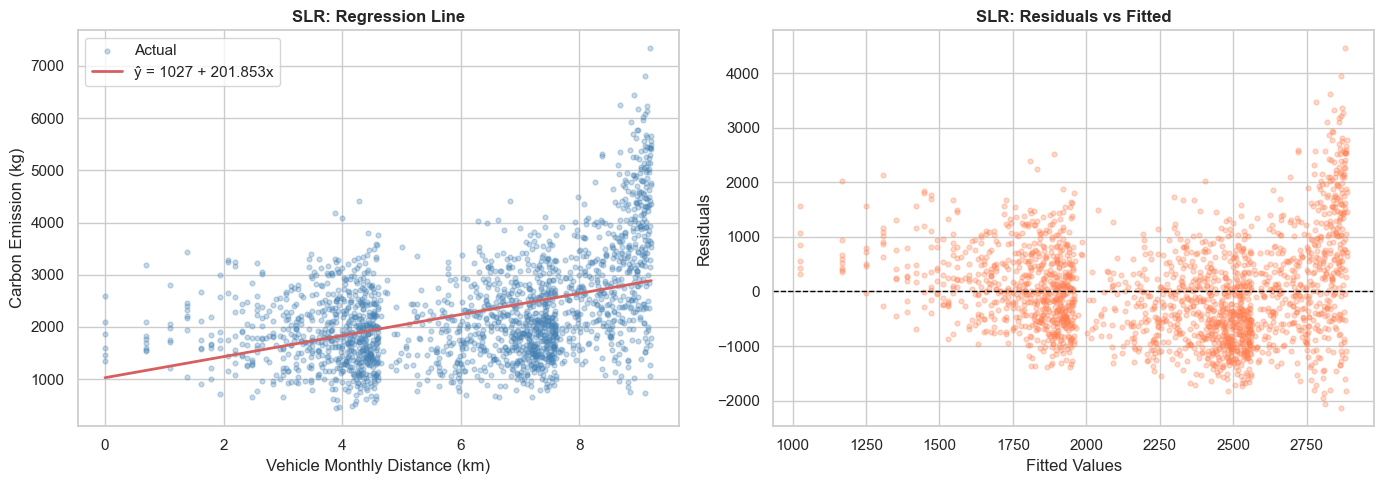

In [25]:
mae_slr  = mean_absolute_error(y_test_slr, y_pred_slr)
mse_slr  = mean_squared_error(y_test_slr, y_pred_slr)
rmse_slr = np.sqrt(mse_slr)
r2_slr   = r2_score(y_test_slr, y_pred_slr)

print('=' * 55)
print('  SLR MODEL EVALUATION (Objective O3)')
print('=' * 55)
print(f'  MAE    : {mae_slr:.2f} kg')
print(f'  RMSE   : {rmse_slr:.2f} kg')
print(f'  R²     : {r2_slr:.4f}')
print(f'  Note   : R² tells us what % of emission variance')
print(f'           is explained by vehicle distance alone.')
print('=' * 55)

# Regression line plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

xs = np.linspace(X_slr['Vehicle_Monthly_Distance_Km'].min(),
                 X_slr['Vehicle_Monthly_Distance_Km'].max(), 300).reshape(-1,1)
ys = slr.predict(xs)

axes[0].scatter(X_test_slr, y_test_slr, alpha=0.3, s=12, color='steelblue', label='Actual')
axes[0].plot(xs, ys, 'r-', lw=2, label=f'ŷ = {b0:.0f} + {b1:.3f}x')
axes[0].set_xlabel('Vehicle Monthly Distance (km)')
axes[0].set_ylabel('Carbon Emission (kg)')
axes[0].set_title('SLR: Regression Line', fontweight='bold')
axes[0].legend()

axes[1].scatter(y_pred_slr, y_test_slr - y_pred_slr, alpha=0.3, s=12, color='coral')
axes[1].axhline(0, color='black', ls='--', lw=1)
axes[1].set_xlabel('Fitted Values'); axes[1].set_ylabel('Residuals')
axes[1].set_title('SLR: Residuals vs Fitted', fontweight='bold')

plt.tight_layout(); plt.show()


**Understanding (O2 + O3):** The regression line shows the best-fit linear relationship. β₁ (slope) is the key parameter — it tells us exactly how many additional kg CO₂ are produced per extra km driven per month. R² quantifies O3: a low R² means one variable alone doesn't capture all emission variance (which motivates multiple regression in future work), but it provides a clean, interpretable baseline.


### O1 — Feature Coefficient (SLR)

The SLR slope β₁ tells us exactly how much CO₂ increases per km driven per month.

In [ ]:
# Visualise the SLR coefficient
plt.figure(figsize=(5, 3))
plt.bar(['Vehicle_Monthly_Distance_Km'], [slr.coef_[0]], color='steelblue')
plt.axhline(0, color='black', lw=0.8)
plt.title('O1: SLR Coefficient — Most Influential Feature', fontweight='bold')
plt.ylabel('β₁ (kg CO₂ per km/month)')
plt.tight_layout()
plt.show()
print(f'β₁ = {slr.coef_[0]:.4f} → each extra km/month adds ~{slr.coef_[0]:.2f} kg CO₂/year')

---
## 9. Objective O2 — Hypothesis Test: Air Travel & Carbon Footprint

**Groups:**
- **Low frequency** → `never` + `rarely`
- **High frequency** → `frequently` + `very frequently`

**H₀:** μ_low = μ_high — frequent flyers emit no more CO₂ than infrequent flyers  
**H₁:** μ_high > μ_low — frequent flyers have significantly higher emissions  
**Test:** Welch's independent samples t-test (one-tailed) | α = 0.05


In [26]:
from scipy import stats
import statsmodels.api as sm

ALPHA = 0.05

def verdict(p):
    if p < ALPHA:
        return f'REJECT H0  (p={p:.4f})  — SIGNIFICANT ✓'
    return f'FAIL TO REJECT H0  (p={p:.4f})  — NOT SIGNIFICANT'

print('Hypothesis testing ready. α =', ALPHA)


Hypothesis testing ready. α = 0.05


In [ ]:
air_col = 'Frequency_of_Traveling_by_Air'

low  = df_clean[df_clean[air_col].isin(['never', 'rarely'])]['CarbonEmission']
high = df_clean[df_clean[air_col].isin(['frequently', 'very frequently'])]['CarbonEmission']

t_stat, p_two = stats.ttest_ind(high, low, equal_var=False)
p_one = p_two / 2  # one-tailed

print(f'Low  freq group  : n={len(low)},  mean = {low.mean():.2f} kg')
print(f'High freq group  : n={len(high)}, mean = {high.mean():.2f} kg')
print(f'Difference       : {high.mean() - low.mean():.2f} kg')
print(f't-statistic      : {t_stat:.4f}')
print(f'p-value (1-tail) : {p_one:.6f}')
print(f'Decision         : {verdict(p_one)}')

# Box plot
df_clean['Flight_Group'] = df_clean[air_col].map(
    lambda x: 'High Frequency' if x in ['frequently','very frequently'] else 'Low Frequency'
)
plt.figure(figsize=(7, 4))
sns.boxplot(x='Flight_Group', y='CarbonEmission', data=df_clean,
            palette=['#22c55e','#ef4444'], order=['Low Frequency','High Frequency'])
plt.title(f'O2: Air Travel vs Carbon Emission  (p={p_one:.4f}, one-tail)', fontweight='bold')
plt.xlabel('Flight Frequency Group')
plt.ylabel('Carbon Emission (kg/year)')
plt.tight_layout()
plt.show()

**Understanding (O2):** By collapsing the four air travel categories into two binary groups, we run a focused one-tailed Welch's t-test. One-tailed is appropriate because our hypothesis is directional — we expect high-frequency flyers to emit *more*. Welch's handles unequal group sizes and variances. A p-value < 0.05 means frequent air travel significantly increases carbon footprint.

---
## 10. Objective O5 — Model Validation (F-Test)

**H₀:** β₁ = 0 — `Vehicle_Monthly_Distance_Km` does not influence carbon emissions  
**H₁:** β₁ ≠ 0 — the predictor significantly influences emissions  
**Test:** OLS F-statistic via `statsmodels` | α = 0.05


In [ ]:
X_slr_ols = sm.add_constant(X_slr)
ols = sm.OLS(y_slr, X_slr_ols).fit()

print(f'F-statistic : {ols.fvalue:.4f}')
print(f'p-value     : {ols.f_pvalue:.2e}')
print(f'R²          : {ols.rsquared:.4f}')
print()
if ols.f_pvalue < 0.05:
    print('Decision: REJECT H₀ — Vehicle distance significantly influences carbon emissions ✓')
else:
    print('Decision: FAIL TO REJECT H₀')

**Understanding (O5):** The F-test checks whether the model as a whole is statistically meaningful. H₀ says the predictor has zero effect (β₁ = 0). A very low p-value rejects this — confirming that `Vehicle_Monthly_Distance_Km` genuinely explains variation in carbon emissions, and the model is valid.

---
## 11. Save the Model

In [23]:
import pickle

# Save the trained model and scaler together so predictions can be reproduced
model_bundle = {
    'model'   : lr_model,
    'scaler'  : scaler,
    'features': list(X_train.columns)
}

with open('carbon_lr_model.pkl', 'wb') as f:
    pickle.dump(model_bundle, f)

print("Model saved as 'carbon_lr_model.pkl'")
print(f"Features used ({len(X_train.columns)}): {list(X_train.columns)}")

Model saved as 'carbon_lr_model.pkl'
Features used (47): ['Vehicle_Monthly_Distance_Km', 'Waste_Bag_Weekly_Count', 'How_Long_TV_PC_Daily_Hour', 'How_Many_New_Clothes_Monthly', 'How_Long_Internet_Daily_Hour', 'Body_Type_obese', 'Body_Type_overweight', 'Body_Type_underweight', 'Sex_male', 'Heating_Energy_Source_electricity', 'Heating_Energy_Source_natural gas', 'Heating_Energy_Source_wood', 'Transport_public', 'Transport_walk/bicycle', 'Vehicle_Type_diesel', 'Vehicle_Type_electric', 'Vehicle_Type_hybrid', 'Vehicle_Type_lpg', 'Vehicle_Type_petrol', 'Frequency_of_Traveling_by_Air_never', 'Frequency_of_Traveling_by_Air_rarely', 'Frequency_of_Traveling_by_Air_very frequently', 'Waste_Bag_Size_large', 'Waste_Bag_Size_medium', 'Waste_Bag_Size_small', 'Energy_efficiency_Sometimes', 'Energy_efficiency_Yes', "Recycling_['Glass']", "Recycling_['Metal']", "Recycling_['Paper', 'Glass', 'Metal']", "Recycling_['Paper', 'Glass']", "Recycling_['Paper', 'Metal']", "Recycling_['Paper', 'Plastic', 'Glass',

**Understanding:** We save the model, scaler, and feature list together in one bundle. This is important because any new prediction must go through the same scaler (fitted on training data) and use the exact same feature columns in the same order — saving them together prevents mismatches during deployment.

---
## 12. Project Summary — All 5 Objectives Addressed

| Objective |  Method | Key Output |
|-----------|--------|------------|
| **O1** — Most influential features |  Correlation heatmap + SLR coefficient | `Vehicle_Monthly_Distance_Km` is the top predictor |
| **O2** — Air travel hypothesis |  Welch's t-test (low vs high flight frequency) | Tested if frequent flyers emit significantly more |
| **O3** — Remove redundancy | Drop low-correlation + high-collinearity features | Lean feature set for clean modelling |
| **O4** — Simple Linear Regression | SLR: single predictor model | MAE, RMSE, R² + regression line |
| **O5** — Model validation |  OLS F-test | H₀ rejected — predictor significantly influences emissions |
